In [ ]:
import sys
sys.path.append("../")
from qiskit.quantum_info import SparsePauliOp
import numpy as np
import pandas as pd
import itertools, os, csv, datetime, ast
from multiprocessing import Pool
from dataclasses import asdict
from collections import Counter

from sympy import im, latex, Matrix # for latex display
from IPython.display import display, Math
from src.utils.utils_visualization import hamiltonian_simplified, hamiltonian_explicit
from qiskit import transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram 

from src.algorithms.algos_qft_qpe_qdrift_latest import qdrift_qpe
import pathlib
from src.parameter_sweep.optimized_driver_factory_function_cache import run_simulation, QPEResult, analyse_counts


# Quick review for my own sanity
As we learned in kindergarden, the effect of QFT on any (pure) state $\ket{j}$ of $t$ qubits is defined as
$$
\ket{j} \rightarrow\frac{1}{\sqrt{2^t}} \sum_{k=0}^{2^t-1} e^{\frac{2\pi i j k}{2^t}} \ket{k}
$$

Where {$k$} is an orthonormal basis. We can also be explicit and use the binary representation: $\ket{k} = \ket{j_1...j_t} = \ket{j_1}\otimes...\otimes \ket{j_t}$. In this representation, applying QFT produces a probability distribution across all possible bitstrings rather than just all integer representations thereof:

$$
\ket{j} \rightarrow\frac{1}{\sqrt{2^t}} \sum_{k_1 = 0}^{1}\sum_{k_2 = 0}^{1} ... \sum_{k_t = 0}^{1} \bigotimes_{l = 1}^t e^{\frac{2 \pi ijk_l}{2^-l}} \ket{k_l} \\

= \frac{1}{\sqrt{2^t}} \big(\ket{0} + e^{2\pi i 0.j_t} \ket{1}\big) \otimes \big(\ket{0} + e^{2\pi i 0.j_{t-1}j_t } \ket{1} \big) \otimes \big(\ket{0} + ^{2\pi i 0.j_{1}...j_{t-1}j_t } \ket{1} \big)
$$

In [127]:
H_one_diag_term = SparsePauliOp(data="ZZ", coeffs=np.pi / 4) 
NUM_ANCILLA = [10]


# Test 1: exact eigenvalue and exact qdrift case



If $\varphi = \frac{2 \pi l}{2^q}$ for some integer $l$ then the effect of QPE on the state vector is
$$ \ket{0}^{\otimes q} \xleftrightarrow{H^{\otimes q}} \frac{1}{\sqrt{2^q}} \sum_{k=0}^{2^q-1} \ket{k} \xleftrightarrow{c-U} \frac{1}{\sqrt{2^q}} \sum_{k=0}^{2^q-1} e^{2 \pi i \varphi k} \ket{k} \xleftrightarrow{QFT^{-1}} \ket{\varphi} $$

where $q$ is the number of ancilla qubits. Hence, we can measure the ancilla register and get $l$ exactly. 

Now, $\varphi$ is determined by the controlled unitary $U = e^{iHt}$, the eigenvector $\ket{\lambda}$ thereof with eigenvalue $\lambda$ AND free parameter $t$, where $t$ is the evloution time. Specifically, 
$$
e^{iHt}\ket{\lambda} = e^{i \lambda t} =  e^{i \varphi} \iff \varphi = \lambda t 
$$

Hence, if we know $\ket{\lambda}$ and $\lambda$ then we can force a "nice" phase. We can simply choose $t$ such that $\lambda = \frac{2\pi l}{t 2^q}$ for whichevcer value of $l$ we want. This is equivalent to choosing $t = \frac{2\pi l}{\lambda_i 2^q}$.




In [135]:
eigenvector_direct = np.array([1,0,0,0]) # with eigenva,]lue ​1.5707963267949
lamb = np.pi /4
display(Math(latex(Matrix(H_one_diag_term))+ latex(Matrix(eigenvector_direct))))

<IPython.core.display.Math object>

So, for a fixed $\lambda$ and $q$ we can just pick some $l \in \{0,...,2^{q-1} \}$, let $t = \frac{2 \pi l}{\lambda 2^q}$ and measure $l$ with 100% probability

In [4]:
q = NUM_ANCILLA[0]
l_lst = np.random.choice(range(2**q), size=10)
t_lst = (2 * np.pi * l_lst) / (lamb * 2**q)
phi_lst = 2 * np.pi * l_lst / 2**q 

df_expected = pd.DataFrame({
    "exact eigenvalue": [lamb] * len(l_lst),
    "l": l_lst,
    "t": t_lst,
    "phi": phi_lst
})
display(df_expected.sort_values(by="l"))

,exact eigenvalue,l,t,phi
7,0.785398,157,1.226562,0.963340
1,0.785398,180,1.406250,1.104466
3,0.785398,384,3.000000,2.356194
5,0.785398,481,3.757812,2.951379
9,0.785398,586,4.578125,3.595651
0,0.785398,623,4.867188,3.822680
2,0.785398,682,5.328125,4.184700
6,0.785398,835,6.523438,5.123496
4,0.785398,984,7.687500,6.037748
8,0.785398,991,7.742188,6.080700


## Un-optimized version:

In [5]:
simulator = AerSimulator()
measured_bitstrings = []
for t in t_lst:
    qc = qdrift_qpe(hamiltonian=H_one_diag_term, time=t, eigenstate=eigenvector_direct, num_qubits=2, num_ancilla=q)
    qc_transpiled = transpile(circuits=qc, optimization_level=3, backend=simulator)
    # print(qc_transpiled)
    job = simulator.run(qc_transpiled, shots=1024)
    result = job.result()
    counts = result.get_counts()
    # print(counts)
    counts_decimal = {int(bitstring, 2) : c for bitstring, c in counts.items()}
    # print(counts_decimal)
    measured_bitstrings.append(counts_decimal)

assert all([len(counts) == 1 for counts in measured_bitstrings]), "All results should have a single count"
plot_histogram(measured_bitstrings)

df_results_simulation_unoptimized = pd.DataFrame({
    "t": t_lst,
    "l_measured": [list(counts.keys())[0] for counts in measured_bitstrings],
    "estimated_phase": [2 * np.pi * list(counts.keys())[0] / 2**q for counts in measured_bitstrings]
})  
df_results_simulation_unoptimized["estimated_eigenvalue"] = df_results_simulation_unoptimized["estimated_phase"] / df_results_simulation_unoptimized["t"]
display(df_results_simulation_unoptimized)


,t,l_measured,estimated_phase,estimated_eigenvalue
0,4.867188,623,3.822680,0.785398
1,1.406250,180,1.104466,0.785398
2,5.328125,682,4.184700,0.785398
3,3.000000,384,2.356194,0.785398
4,7.687500,984,6.037748,0.785398
5,3.757812,481,2.951379,0.785398
6,6.523438,835,5.123496,0.785398
7,1.226562,157,0.963340,0.785398
8,7.742188,991,6.080700,0.785398
9,4.578125,586,3.595651,0.785398


## Optimized version

In [8]:
basename = f"qdrift_qpe_fc_parameter_sweep_{datetime.datetime.today():%Y-%m-%d}"
csv_path = pathlib.Path(f"{basename}.csv")

NUM_QDRIFT_SEGMENTS_PER_CHANNEL_SAMPLE = [1]
REPLICATION_SEEDS = [42]
RANDOM_CIRCUITS_PER_DATAPOINT = [1]
SHOTS_PER_CIRCUIT = [1024] # we can get away with this because there is just one term
ESTIMATE_GROUND_STATE = [False]

grid = itertools.product(["exact_ham_exact_qdritf"], NUM_ANCILLA, t_lst, NUM_QDRIFT_SEGMENTS_PER_CHANNEL_SAMPLE, REPLICATION_SEEDS, RANDOM_CIRCUITS_PER_DATAPOINT, SHOTS_PER_CIRCUIT, ESTIMATE_GROUND_STATE)
cfgs = [dict(ham=g[0], anc=g[1], time=float(g[2]), segments=g[3], replication_seed=g[4], circuits=g[5], shots=g[6], ground_state=g[7]) for g in grid]

if not csv_path.exists():
    with csv_path.open("w", newline="") as fh:
        csv.DictWriter(
            fh,
            fieldnames = QPEResult.__dataclass_fields__.keys() # write header only once (and only if the file does not exist)
        ).writeheader()

# run the sweep in parallel
n_proc = min(os.cpu_count() or 1, 16)
with Pool(processes=n_proc//2) as pool:
    print(f"Running {len(cfgs)} configurations in parallel on {pool._processes} workers.")
    for result in pool.imap_unordered(run_simulation, cfgs):
        with csv_path.open("a", newline="") as fh:
            csv.DictWriter(
                fh,
                fieldnames = QPEResult.__dataclass_fields__.keys()
            ).writerow(asdict(result))



Running 10 configurations in parallel on 4 workers.
Running worker from process 74328
Running worker from process 74331
Running worker from process 74329
Running worker from process 74330
Running worker from process 74331
Running worker from process 74330
Running worker from process 74329
Running worker from process 74328
Running worker from process 74331
Running worker from process 74330


In [ ]:
import seaborn as sns
import pandas as pd
df = pd.read_csv("/Users/reyesfer/Desktop/qDriftExtraPolation/notebooks/qdrift_qpe_fc_parameter_sweep_2025-08-19.csv")
df ["counts_dec"] = df["counts"].apply(lambda x : int(list(ast.literal_eval(x).keys())[0], 2))
df["estimated_phase"] = df["counts"].apply(lambda x : int(list(ast.literal_eval(x).keys())[0], 2) / 2 ** q)
df["est_energy_median_no_wrap_correction"] = df.apply(
    lambda row: analyse_counts(
        counts=ast.literal_eval(row["counts"]),
        t=row["time"],
        m=q,
        wrapp_around_correction=False
    )[1], # We select the 1st index for the median energy (e_med)
    axis=1
)
# sort by measured bitstrings
df = df.sort_values(by="counts_dec")
df = df.reset_index(drop=True)
df[["counts", "counts_dec", "estimated_phase", "est_energy_med", "time", "est_energy_median_no_wrap_correction"]]

,counts,counts_dec,estimated_phase,est_energy_med,time,est_energy_median_no_wrap_correction
0,"{""0001000000"": 1024}",64,0.062500,0.785398,0.500000,0.785398
1,"{""0010010101"": 1024}",149,0.145508,0.785398,1.164062,0.785398
2,"{""0110110110"": 1024}",438,0.427734,0.785398,3.421875,0.785398
3,"{""1001111011"": 1024}",635,0.620117,-0.481134,4.960938,0.785398
4,"{""1010110000"": 1024}",688,0.671875,-0.383567,5.375000,0.785398
5,"{""1100011000"": 1024}",792,0.773438,-0.230066,6.187500,0.785398
6,"{""1100011010"": 1024}",794,0.775391,-0.227508,6.203125,0.785398
7,"{""1100111001"": 1024}",825,0.805664,-0.189448,6.445313,0.785398
8,"{""1101101100"": 1024}",876,0.855469,-0.132693,6.843750,0.785398
9,"{""1111000010"": 1024}",962,0.939453,-0.050618,7.515625,0.785398


# Test 2: exact eigenvalue and many terms
- qDRIFT channel has nontrivial action
$$
d(\varepsilon, \mathcal{U_N})_\diamond \leq \frac{2 \alpha^2 t^2}{N^2} e^{\frac{2 \alpha t}{N}} \approx \frac{2 \alpha^2 t^2}{N^2} \\

$$
and 

$$
 | \lambda - \tilde{\lambda}| = \big| \frac{\theta}{t} - \frac{\tilde{\theta}}{t} \big| = \frac{1}{t} \big| \theta -  \tilde{\theta} \big| 

$$

Therefore, qDRIFT error is

$$
| \lambda - \tilde{\lambda}| \leq \frac{1}{t} d(\varepsilon, \mathcal{U_N})_\diamond =  \frac{2 \alpha^2 t}{N^2} e^{\frac{2 \alpha t}{N}}
$$

- QPE error is (probably) no longer zero; idk what it is exact, but for sure:

$$
 | \lambda - \tilde{\lambda}| = \frac{1}{t} \big| \theta -  \tilde{\theta} \big| \leq \frac{2 \pi}{t 2^n}

 $$

theoretica total error ???





In [136]:
H_many_diag_terms = SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([1/10, -2/10, 3/10, 4/10]))
nice_format = hamiltonian_explicit(H_many_diag_terms)
display(Math(nice_format))
display(Math(latex(Matrix(H_many_diag_terms))+ latex(Matrix(eigenvector_direct)) + "= 0.6" + latex(Matrix(eigenvector_direct))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [159]:
q = NUM_ANCILLA[0]
l_lst = np.random.choice(range(2**(q - 5)), size=9)
lamb = 0.6
t_lst = (2 * np.pi * l_lst) / (lamb * 2**q)
phi_lst = 2 * np.pi * l_lst / 2**q 

alpha = sum(abs(H_many_diag_terms.coeffs)) 
print(f"alpha = {alpha}")
max_qdrift_error = 2 * alpha**2 * t_lst * np.exp(2 * alpha * t_lst)
sorted(t_lst)

alpha = 1.0


[np.float64(0.010226538585904275),
 np.float64(0.0409061543436171),
 np.float64(0.05113269292952138),
 np.float64(0.06135923151542565),
 np.float64(0.07158577010132992),
 np.float64(0.15339807878856412),
 np.float64(0.21475731030398978),
 np.float64(0.2863430804053197),
 np.float64(0.30679615757712825)]

## Un-optimized version:

In [160]:
simulator = AerSimulator()
# outer dictionaries: one Counter per evolution time t
measured_dec   = {t: Counter() for t in t_lst}   # decimal
measured_bin   = {t: Counter() for t in t_lst}   # binary strings
num_independent_stochastic_circuits_per_datapoint = 100
shots_per_circuit = 1
q = NUM_ANCILLA[0]
print(f"Running {len(t_lst) * num_independent_stochastic_circuits_per_datapoint} circuits in total, with {q} ancilla qubits each.")
for t in t_lst:
    counter = 0
    print(f"t = {t}: ")
    for _ in range(num_independent_stochastic_circuits_per_datapoint): 
        counter += 1
        qc = qdrift_qpe(hamiltonian=H_many_diag_terms, time=t, eigenstate=eigenvector_direct, num_qubits=2, num_ancilla=q)
        qc_t      = transpile(qc, backend=simulator, optimization_level=3)
        result    = simulator.run(qc_t, shots=shots_per_circuit).result()

        counts_bin = result.get_counts()                       # e.g. {'101':1}
        counts_dec = {int(bs, 2): c for bs, c in counts_bin.items()}

        measured_bin[t].update(counts_bin)   # binary outcomes
        measured_dec[t].update(counts_dec)   # decimal outcomes

Running 900 circuits in total, with 10 ancilla qubits each.
t = 0.30679615757712825: 
t = 0.15339807878856412: 
t = 0.21475731030398978: 
t = 0.0409061543436171: 
t = 0.06135923151542565: 
t = 0.2863430804053197: 
t = 0.07158577010132992: 
t = 0.05113269292952138: 
t = 0.010226538585904275: 


In [22]:
# helpers

import matplotlib.pyplot as plt
import math
import statistics

def plot_histograms(dicts, titles=None, max_plots=12,
                    bar_kw=None, figsize=(12, 8),
                    suptitle=None, show_bitstrings=False):
    n = min(len(dicts), max_plots)
    if len(dicts) > max_plots:
        print(f"⚠  Only the first {max_plots} histograms will be drawn.")

    bar_kw = bar_kw or {}
    cols = 3
    rows  = math.ceil(n / cols)          # ⩽3×3 grid

    fig, axes = plt.subplots(rows, cols, figsize=figsize,
                              constrained_layout=True)
    axes = axes.flatten()            # 1-D view even if figure is 2-D

    for i in range(n):
        ax   = axes[i]
        data = dicts[i]
        keys = [int(bs, 2) for bs in data.keys()] if not show_bitstrings else list(data.keys())
        vals = list(data.values())

        ax.bar(range(len(keys)), vals, **bar_kw)
        ax.set_xticks(range(len(keys)), keys, rotation=45)
        ax.set_ylabel("counts")

        if titles:
            ax.set_title(titles[i])
    # hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle)
    plt.show()

def median_from_counter(counter):
    if not counter:          # empty dict ⇒ NaN
        return np.nan
    expanded = [val for val, freq in counter.items() for _ in range(freq)]
    return statistics.median(expanded)

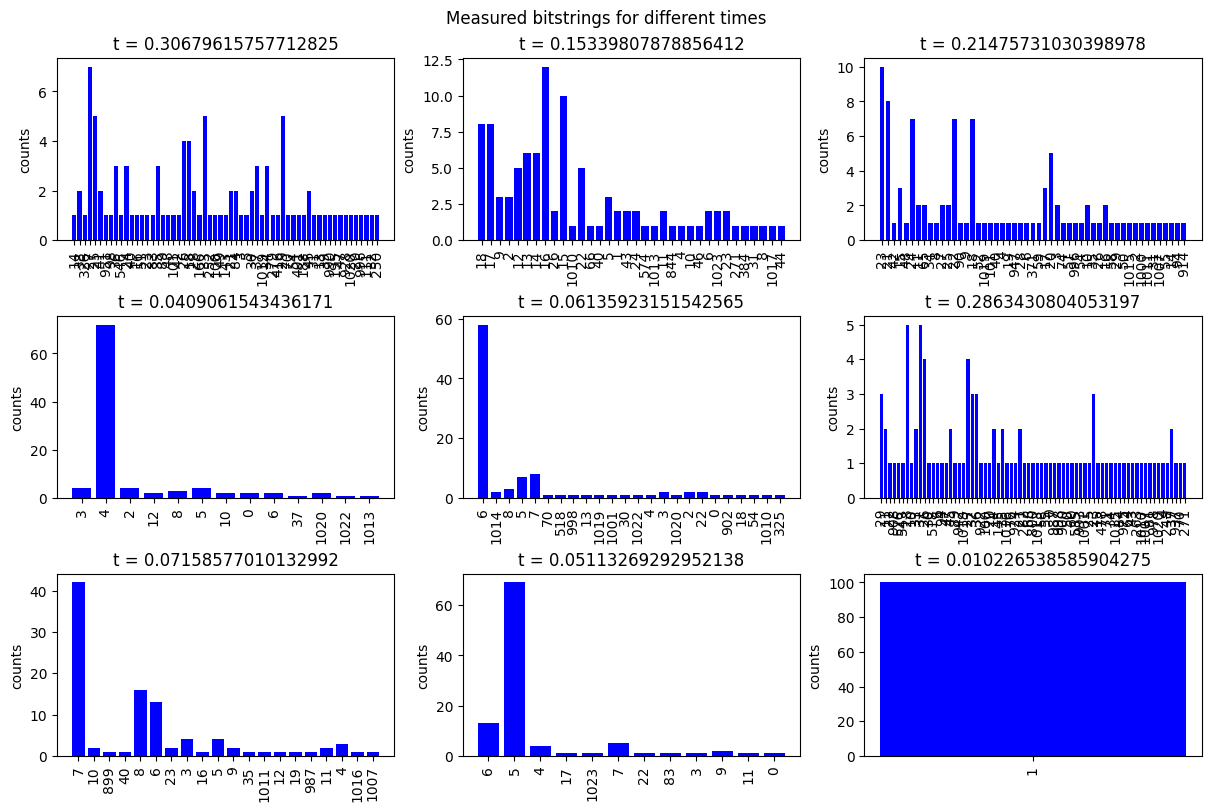

In [173]:
plot_histograms(
    [measured_dec[t] for t in t_lst],
    titles=[f"t = {t}" for t in t_lst],
    bar_kw={"color": "blue", "width": 0.8},
    figsize=(12, 8),
    suptitle="Measured bitstrings for different times"
)

In [169]:

df_results_simulation_unoptimized = pd.DataFrame({
    "t"            : t_lst,
    "most freq l"  : [max(measured_dec[t], key=measured_dec[t].get, default=np.nan) for t in t_lst],
    "median l"     : [median_from_counter(measured_dec[t]) for t in t_lst],
    "estimated_phase" : [2 * np.pi * median_from_counter(measured_dec[t]) / 2**q for t in t_lst],
    
}).sort_values("t")

df_results_simulation_unoptimized["estimated_phase"] = df_results_simulation_unoptimized["median l"] / 2**q
df_results_simulation_unoptimized["estimated_eigenvalue"] = 2* np.pi * df_results_simulation_unoptimized["estimated_phase"] / df_results_simulation_unoptimized["t"]
df_results_simulation_unoptimized["true_eigenvalue"] = lamb
display(df_results_simulation_unoptimized)

,t,most freq l,median l,estimated_phase,estimated_eigenvalue,true_eigenvalue
8,0.010227,1,1.0,0.000977,0.600000,0.6
3,0.040906,4,4.0,0.003906,0.600000,0.6
7,0.051133,5,5.0,0.004883,0.600000,0.6
4,0.061359,6,6.0,0.005859,0.600000,0.6
6,0.071586,7,7.0,0.006836,0.600000,0.6
1,0.153398,16,16.0,0.015625,0.640000,0.6
2,0.214757,23,23.0,0.022461,0.657143,0.6
5,0.286343,28,36.5,0.035645,0.782143,0.6
0,0.306796,27,34.0,0.033203,0.680000,0.6


## Optimized version

In [ ]:
import pathlib
from src.parameter_sweep.optimized_driver_factory_function_cache import run_simulation, QPEResult, analyse_counts

basename = f"qdrift_qpe_fc_parameter_sweep_10_{datetime.datetime.today():%Y-%m-%d}"
csv_path = pathlib.Path(f"{basename}.csv")

NUM_QDRIFT_SEGMENTS_PER_CHANNEL_SAMPLE = [1]
REPLICATION_SEEDS = [42]
RANDOM_CIRCUITS_PER_DATAPOINT = [100]
SHOTS_PER_CIRCUIT = [1]
ESTIMATE_GROUND_STATE = [False]

grid = itertools.product(["H_many_diag_terms"], NUM_ANCILLA, t_lst, NUM_QDRIFT_SEGMENTS_PER_CHANNEL_SAMPLE, REPLICATION_SEEDS, RANDOM_CIRCUITS_PER_DATAPOINT, SHOTS_PER_CIRCUIT, ESTIMATE_GROUND_STATE)
cfgs = [dict(ham=g[0], anc=g[1], time=float(g[2]), segments=g[3], replication_seed=g[4], circuits=g[5], shots=g[6], ground_state=g[7]) for g in grid]

if not csv_path.exists():
    with csv_path.open("w", newline="") as fh:
        csv.DictWriter(
            fh,
            fieldnames = QPEResult.__dataclass_fields__.keys() # write header only once (and only if the file does not exist)
        ).writeheader()

# run the sweep in parallel
n_proc = min(os.cpu_count() or 1, 16)
with Pool(processes=n_proc - 2) as pool:
    print(f"Running {len(cfgs)} configurations in parallel on {pool._processes} workers.")
    for result in pool.imap_unordered(run_simulation, cfgs):
        with csv_path.open("a", newline="") as fh:
            csv.DictWriter(
                fh,
                fieldnames = QPEResult.__dataclass_fields__.keys()
            ).writerow(asdict(result))


Running 9 configurations in parallel on 6 workers.
Running worker from processRunning worker from process  4369243695

Running worker from process 43693
Running worker from process 43694
Running worker from process 43696
Running worker from process 43691
Running worker from process 43694
Running worker from process 43691
Running worker from process 43696


⚠  Only the first 12 histograms will be drawn.


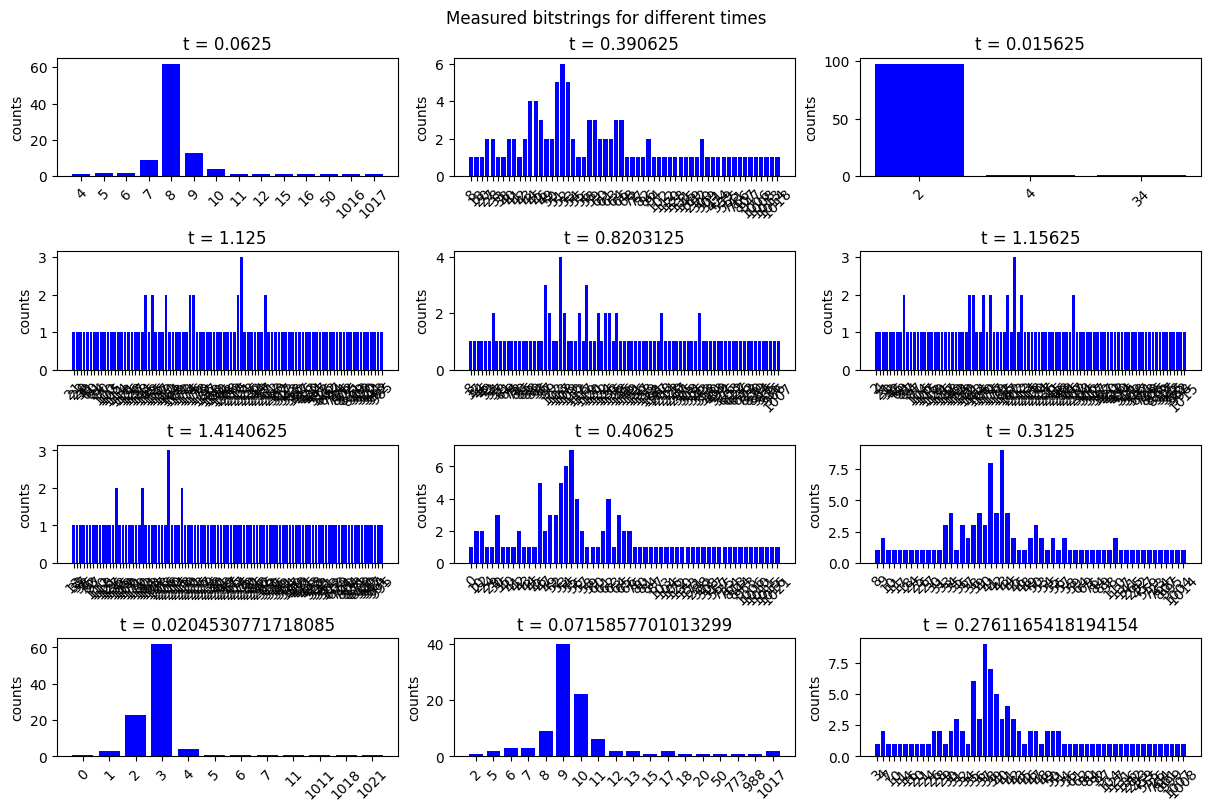

,time,estimated_phase,est_energy_med,est_energy_median_no_wrap_correction,exact_eig,estimation_error
0,0.010227,0.000000,0.600000,0.037500,0.8,2.000000e-01
1,0.015625,0.000122,0.785398,0.049087,0.8,1.460184e-02
2,0.020453,0.000000,0.900000,0.056250,0.8,1.000000e-01
3,0.062500,0.000244,0.785398,0.049087,0.8,1.460184e-02
4,0.071586,0.000122,0.771429,0.048214,0.8,2.857143e-02
5,0.071586,0.000122,0.771429,0.048214,0.8,2.857143e-02
6,0.092039,0.000244,0.800000,0.050000,0.8,1.110223e-16
7,0.173851,0.000427,0.811765,0.052941,0.8,1.176471e-02
8,0.276117,0.000183,0.844444,0.054167,0.8,4.444444e-02
9,0.306796,0.000427,0.820000,0.052500,0.8,2.000000e-02


In [24]:
df = pd.read_csv("/Users/reyesfer/Desktop/qDriftExtraPolation/notebooks/qdrift_qpe_fc_parameter_sweep_10_2025-08-21.csv")

plot_histograms(
    [ast.literal_eval(row["counts"]) for _, row in df.iterrows()],
    titles=[f"t = {row['time']}" for _, row in df.iterrows()],
    bar_kw={"color": "blue", "width": 0.8},
    figsize=(12, 8),
    suptitle="Measured bitstrings for different times"
)

df ["counts_dec"] = df["counts"].apply(lambda x : int(list(ast.literal_eval(x).keys())[0], 2))
df["estimated_phase"] = df["counts"].apply(lambda x : int(list(ast.literal_eval(x).keys())[0], 2) / 2 ** q)
df["est_energy_median_no_wrap_correction"] = df.apply(
    lambda row: analyse_counts(
        counts=ast.literal_eval(row["counts"]),
        t=row["time"],
        m=q,
        wrapp_around_correction=False
    )[1], # We select the 1st index for the median energy (e_med)
    axis=1
)
# sort by measured bitstrings
df = df.sort_values(by="time")
df = df.reset_index(drop=True)
df[["time", "estimated_phase", "est_energy_med", "est_energy_median_no_wrap_correction", "exact_eig", "estimation_error"]]

In [ ]:
q = 15
l_lst = np.random.choice(range(2**(q//2 + 2)), size=10)
lamb = 0.8 # highest eigenvalue
t_lst = (2 * np.pi * l_lst) / (lamb * 2**q)
phi_lst = 2 * np.pi * l_lst / 2**q 

alpha = sum(abs(H_many_diag_terms.coeffs)) 
print(f"alpha = {alpha}")
max_qdrift_error = 2 * alpha**2 * t_lst * np.exp(2 * alpha * t_lst)
max_qpe_error = 2 * np.pi / (2**q * t_lst)

df_expected = pd.DataFrame({
    "exact eigenvalue": [lamb] * len(l_lst),
    "l": l_lst,
    "t": t_lst,
    "phi": phi_lst,
    "max_qdrift_error": max_qdrift_error,
    "max_qpe_error": max_qpe_error
})
display(df_expected.sort_values(by="l"))

alpha = 1.0


,exact eigenvalue,l,t,phi,max_qdrift_error
2,0.8,23,0.005513,0.004410,0.011148
7,0.8,67,0.016059,0.012847,0.033166
4,0.8,122,0.029242,0.023393,0.062005
6,0.8,125,0.029961,0.023968,0.063621
5,0.8,201,0.048177,0.038541,0.106099
0,0.8,255,0.061120,0.048896,0.138133
3,0.8,261,0.062558,0.050046,0.141791
8,0.8,329,0.078856,0.063085,0.184654
9,0.8,355,0.085088,0.068070,0.201746
1,0.8,418,0.100188,0.080150,0.244832


## optimized versio more qubits

In [2]:
import pathlib
from src.parameter_sweep.optimized_driver_factory_function_cache import run_simulation, QPEResult, analyse_counts
from src.error_analysis.theoretical_error_the_dumb_version import RegimeConfig, sample_t_from_regimes, plot_errors_with_shading_and_edge_labels
import matplotlib.pyplot as plt
import numpy as np

In [3]:
hamiltonians = {
    "H_many_diag_terms_1" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([1/10, 2/10, 3/10, 4/10])),
    "H_many_diag_terms_3" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([4/5, 2/3, 4/5, 4/5])),
    "H_many_diag_terms_0.5" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([2/20, 1/20, 3/20, 4/20]))
}
lamda_lst = []
for ham_name, ham in hamiltonians.items():
    # display(Math(latex(Matrix(H_one_diag_term))+ latex(Matrix(eigenvector_direct))))
    display(Math(latex(Matrix(ham))))
    eigvals, _ = np.linalg.eig(ham.to_matrix())
    print("highest eigenvalue:", np.max(eigvals).real)
    lamdaa   = np.sum(np.abs(ham.coeffs))
    print("lambda:", lamdaa)
    lamda_lst.append(lamdaa)

<IPython.core.display.Math object>

highest eigenvalue: 1.0
lambda: 1.0


<IPython.core.display.Math object>

highest eigenvalue: 3.0666666666666664
lambda: 3.0666666666666664


<IPython.core.display.Math object>

highest eigenvalue: 0.5
lambda: 0.5


In [4]:
basename = f"qdrift_qpe_fc_parameter_sweep_14_{datetime.datetime.today():%Y-%m-%d}"
csv_path = pathlib.Path(f"{basename}.csv")

NUM_QDRIFT_SEGMENTS_PER_CHANNEL_SAMPLE = [1]
REPLICATION_SEEDS = [42]
RANDOM_CIRCUITS_PER_DATAPOINT = [1000]
SHOTS_PER_CIRCUIT = [1]
ESTIMATE_GROUND_STATE = [False]
NUM_ANCILLA = [14]


In [6]:
results_csv_paths = []
for hamiltonian_name, H in hamiltonians.items():
    print(f"{hamiltonian_name}: {time_values[hamiltonian_name]}")
    grid = itertools.product([hamiltonian_name], NUM_ANCILLA, time_values[hamiltonian_name], NUM_QDRIFT_SEGMENTS_PER_CHANNEL_SAMPLE, REPLICATION_SEEDS, RANDOM_CIRCUITS_PER_DATAPOINT, SHOTS_PER_CIRCUIT, ESTIMATE_GROUND_STATE)
    cfgs = [dict(ham=g[0], anc=g[1], time=float(g[2]), segments=g[3], replication_seed=g[4], circuits=g[5], shots=g[6], ground_state=g[7]) for g in grid]

    csv_path = pathlib.Path(f"{basename}_{hamiltonian_name}.csv")
    results_csv_paths.append(csv_path)
    """
    if not csv_path.exists():
        with csv_path.open("w", newline="") as fh:
            csv.DictWriter(
                fh,
                fieldnames = QPEResult.__dataclass_fields__.keys() # write header only once (and only if the file does not exist)
            ).writeheader()
    # run the sweep in parallel
    n_proc = min(os.cpu_count() or 1, 16)
    with Pool(processes=n_proc//2) as pool:
        print(f"Running {len(cfgs)} configurations in parallel on {pool._processes} workers.")
        for result in pool.imap_unordered(run_simulation, cfgs):
            with csv_path.open("a", newline="") as fh:
                csv.DictWriter(
                    fh,
                    fieldnames = QPEResult.__dataclass_fields__.keys()
                ).writerow(asdict(result))
                print(f"Wrote result for configuration: {cfg}")   """


H_many_diag_terms_1: [0.00782364 0.00786454 0.00789535 0.0079045  0.00791463 0.0091122
 0.01185167 0.01291865 0.0180881  0.01858306 0.0216422  0.02281831
 0.0271054  0.03937007 0.06450708 0.08315456 0.10196477 0.15343039]
H_many_diag_terms_3: [0.00949395 0.01052783 0.0118173  0.0165611  0.0269999  0.03404308
 0.03457289 0.03540335 0.05047977 0.06841183 0.08208106 0.10198552
 0.10653427 0.11101793 0.12579269 0.14211651 0.17924182 0.21168105]
H_many_diag_terms_0.5: [0.01143138 0.01294929 0.0142184  0.01461779 0.01507223 0.0182244
 0.02370335 0.0258373  0.03617619 0.03716612 0.04328441 0.04563663
 0.05186507 0.06726522 0.09487601 0.11323206 0.1305141  0.17348641]


In [7]:
q= 14
result_dfs = []
results_csv_paths = ["qdrift_qpe_fc_parameter_sweep_14_2025-08-30_H_many_diag_terms_0.5.csv", "qdrift_qpe_fc_parameter_sweep_14_2025-08-30_H_many_diag_terms_1.csv", "qdrift_qpe_fc_parameter_sweep_14_2025-08-30_H_many_diag_terms_3.csv"]
for filename in results_csv_paths:
    df = pd.read_csv(filename)
    df ["counts_dec"] = df["counts"].apply(lambda x : int(list(ast.literal_eval(x).keys())[0], 2))
    df["estimated_phase"] = df["counts"].apply(lambda x : int(list(ast.literal_eval(x).keys())[0], 2) / 2 ** q)
    df["max_theoretical_qpe_error"] = 2 * np.pi / (2**q * df["time"])
    df.sort_values(by="estimation_error", ascending=True, inplace=True)
    result_dfs.append(df)

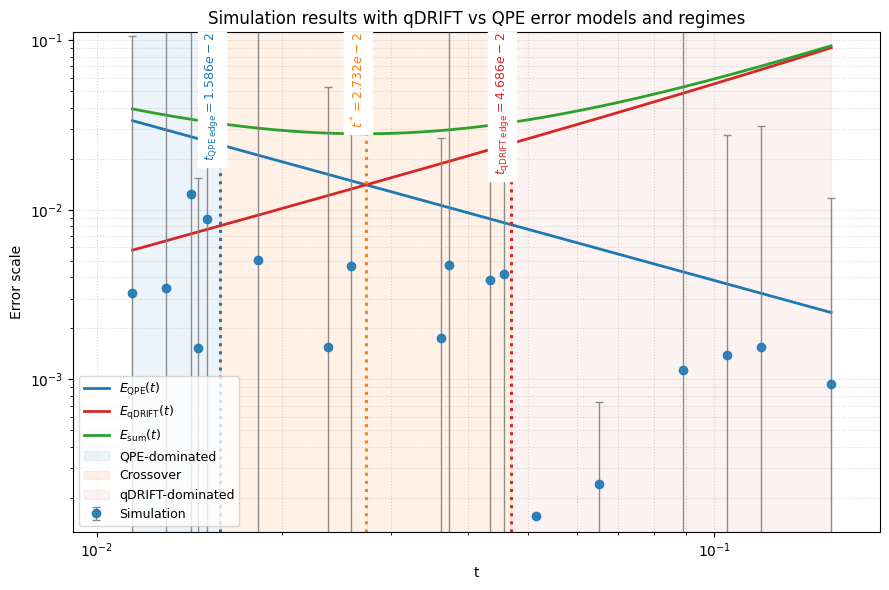

,estimated_phase,est_energy_med,est_energy_std,time,exact_eig,estimation_error,max_theoretical_qdrift_error,max_theoretical_qpe_error
12,0.004089,0.499843,0.000000,0.051405,0.5,0.000157,0.027058,0.007460
13,0.005066,0.500243,0.000492,0.065162,0.5,0.000243,0.034775,0.005885
17,0.006226,0.500940,0.010863,0.154641,0.5,0.000940,0.090252,0.002480
14,0.005493,0.498857,0.148604,0.089175,0.5,0.001143,0.048746,0.004300
15,0.002563,0.501387,0.026247,0.104787,0.5,0.001387,0.058182,0.003660
0,0.000183,0.498462,0.013811,0.014618,0.5,0.001538,0.007417,0.026235
16,0.006836,0.501543,0.029557,0.119282,0.5,0.001543,0.067197,0.003215
6,0.000488,0.501547,0.051105,0.023703,0.5,0.001547,0.012136,0.016179
8,0.000183,0.498236,0.024916,0.036176,0.5,0.001764,0.018754,0.010601
1,0.000000,0.503214,0.103210,0.011431,0.5,0.003214,0.005781,0.033548


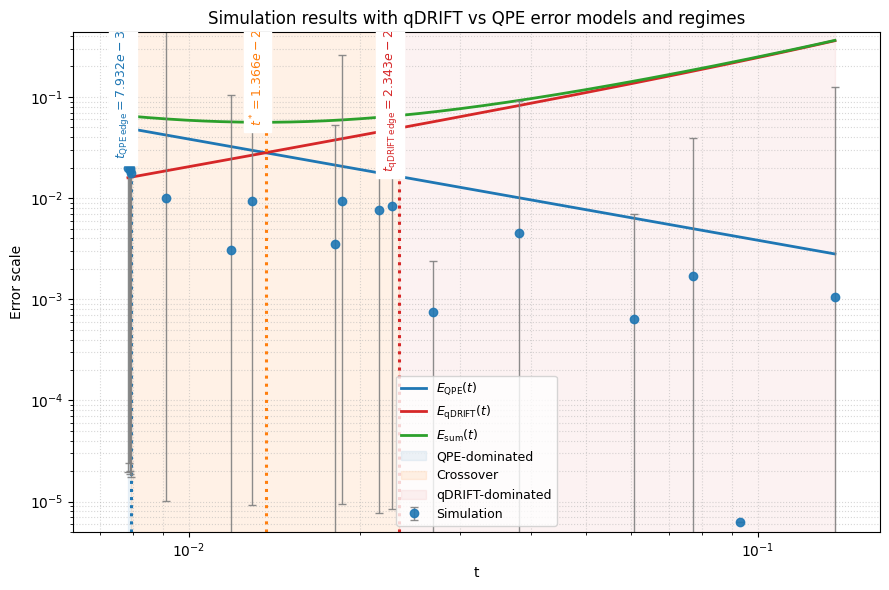

,estimated_phase,est_energy_med,est_energy_std,time,exact_eig,estimation_error,max_theoretical_qdrift_error,max_theoretical_qpe_error
16,0.014832,0.999994,0.000000,0.093190,1.0,0.000006,0.224565,0.004115
13,0.008423,0.999365,0.006257,0.060631,1.0,0.000635,0.136895,0.006325
12,0.004150,0.999254,0.001628,0.026865,1.0,0.000746,0.056695,0.014275
17,0.010315,1.001052,0.124147,0.136764,1.0,0.001052,0.359578,0.002804
15,0.002563,1.001687,0.037521,0.076953,1.0,0.001687,0.179512,0.004984
6,0.000488,1.003095,0.102209,0.011852,1.0,0.003095,0.024272,0.032358
8,0.000183,0.996472,0.049832,0.018088,1.0,0.003528,0.037509,0.021202
14,0.003235,0.995455,0.086062,0.038139,1.0,0.004545,0.082325,0.010055
11,0.000244,0.992308,0.793344,0.021642,1.0,0.007692,0.045199,0.017720
10,0.000366,1.008388,0.186734,0.022818,1.0,0.008388,0.047768,0.016806


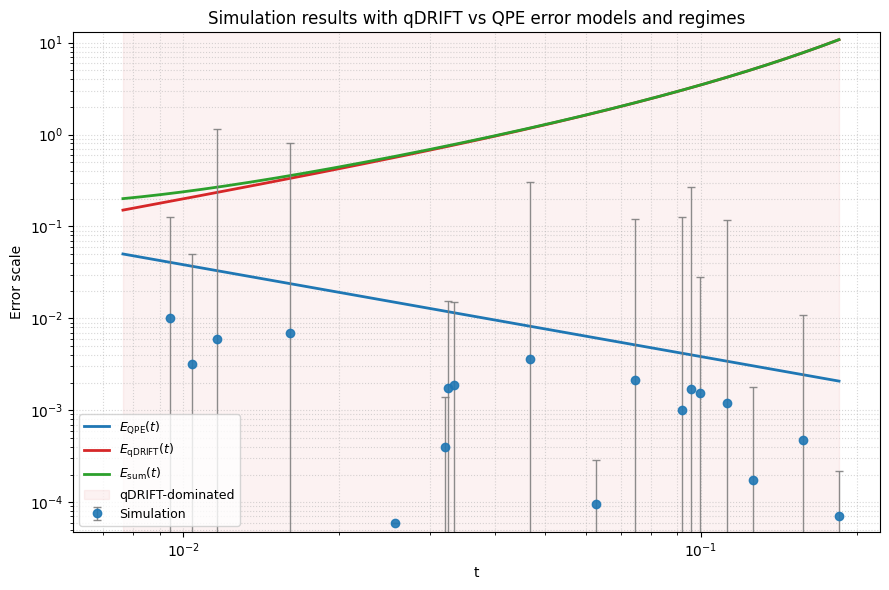

,estimated_phase,est_energy_med,est_energy_std,time,exact_eig,estimation_error,max_theoretical_qdrift_error,max_theoretical_qpe_error
6,0.012512,3.066608,0.000000,0.025636,3.066667,0.000059,0.564294,0.014959
17,0.090027,3.066738,0.000147,0.184699,3.066667,0.000071,10.784594,0.002076
9,0.030457,3.066761,0.000194,0.062524,3.066667,0.000095,1.725670,0.006134
15,0.061340,3.066839,0.001602,0.126046,3.066667,0.000172,5.136157,0.003042
4,0.015564,3.066267,0.001002,0.032018,3.066667,0.000400,0.732888,0.011978
16,0.069763,3.066189,0.010470,0.157466,3.066667,0.000477,7.780145,0.002435
11,0.043762,3.065667,0.125697,0.091694,3.066667,0.001000,3.026522,0.004182
14,0.052429,3.067869,0.115311,0.112128,3.066667,0.001203,4.195193,0.003420
13,0.045898,3.065112,0.026721,0.099467,3.066667,0.001555,3.443440,0.003855
12,0.043091,3.068382,0.268412,0.095612,3.066667,0.001716,3.232614,0.004011


In [9]:
# plot estimation error and max theoretical error vs time
from src.error_analysis.theoretical_error_the_dumb_version import plot_sim_results_with_regimes
for df in result_dfs:
    plot_sim_results_with_regimes(df=df, alpha=df["alpha"].iloc(0)[0], m=NUM_ANCILLA[0], N=1)

    display(df[[ "estimated_phase", "est_energy_med", "est_energy_std", "time", "exact_eig", "estimation_error", "max_theoretical_qdrift_error", "max_theoretical_qpe_error"]])
    

## Extra stuff

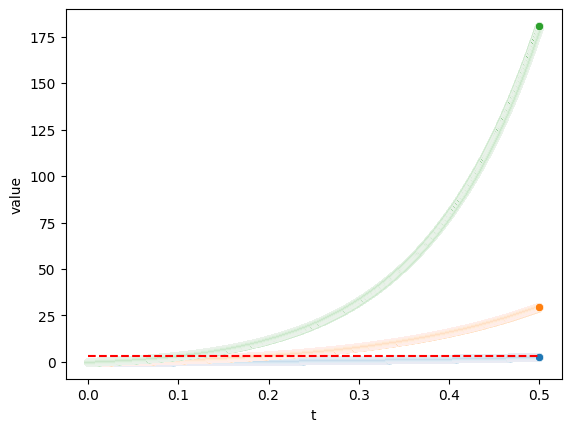

In [31]:
from matplotlib.pyplot import hlines
import seaborn as sns
green_tea = np.linspace(0.00001, 0.5, 10000)
sugar = 1
sugar2 = 2
sugar3 = 3

df = pd.DataFrame()
df["t"] = green_tea
df["value"] = 2 * sugar ** 2 * green_tea * np.exp(2 * sugar * green_tea)
df["value2"] = 2 * sugar2 ** 2 * green_tea * np.exp(2 * sugar2 * green_tea)
df["value3"] = 2 * sugar3 ** 2 * green_tea * np.exp(2 * sugar3 * green_tea)

sns.scatterplot(data=df, x="t", y="value")
sns.scatterplot(data=df, x="t", y="value2")
sns.scatterplot(data=df, x="t", y="value3")
hlines(np.pi, xmin=0, xmax=0.5, color="red", linestyle="--")
